# 🎯 LSH + MinHash (Recomendaciones) — Netflix EDA

**Sistema de Recomendación por Co-Visionado**  
Curso: Estructuras de Datos y Algoritmos | UTEC

---

## Fundamentos Matemáticos

### Similitud de Jaccard

Mide qué tan similares son dos conjuntos:
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Para videos: Si A = usuarios que vieron "Stranger Things" y B = usuarios que vieron "Dark", J(A,B) alta → videos similares → buenos para recomendar juntos.

### MinHash

Estima la similitud de Jaccard sin comparar los conjuntos completos. La idea clave:
> **La probabilidad de que h_min(A) = h_min(B) es exactamente J(A, B)**

Usando `k` funciones hash independientes, se obtiene una firma de `k` valores que permite estimar J con error ≈ 1/√k.

### LSH (Locality Sensitive Hashing)

Permite encontrar candidatos similares sin comparar todos los pares O(n²):
1. Dividir la firma en `b` bandas de `r` filas cada una
2. Dos videos son candidatos si **al menos una banda** tiene la misma sub-firma
3. Probabilidad de ser candidatos con similitud s: P = 1 - (1 - s^r)^b

### Uso en Netflix

Con 100M+ videos, comparar todos los pares sería O(n²) = 10¹⁶ operaciones. LSH lo reduce a ~O(n).

In [11]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/Guido-Silva/netflix-streaming-eda.git
    %cd netflix-streaming-eda
    PROJECT_ROOT = Path.cwd().resolve()
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

INFORME_DIR = PROJECT_ROOT / "informe"
INFORME_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entorno configurado | PROJECT_ROOT={PROJECT_ROOT}")


Entorno configurado | PROJECT_ROOT=C:\Users\jsilvac\Documents\UTEC Maestria\2do ciclo\Estructuras de Datos y Algoritmos\Proyecto Final\netflix-streaming-eda


In [12]:
from src.lsh_minhash import LSHMinHash, MinHash
print('✅ Módulo LSH + MinHash importado')

✅ Módulo LSH + MinHash importado


In [13]:
from src.lsh_minhash import demo
# Ejecuta esta celda solo si quieres ver la demostracion completa:
# demo()


In [14]:
# =========================================================
# EXPERIMENTO: Precision de MinHash vs numero de hashes (k)
# Con repeticiones, std y grafico log-log
# =========================================================

import random
import numpy as np
import math
import statistics
import matplotlib.pyplot as plt
import time

print('Experimento: Precision de MinHash vs Numero de Hashes')
print('=' * 70)

# -------------------------------
# Parametros
# -------------------------------
random.seed(42)
np.random.seed(42)
N_USUARIOS = 500
todos_usuarios = [f'u{i}' for i in range(N_USUARIOS)]

similitudes_objetivo = [0.1, 0.3, 0.5, 0.7, 0.9]
num_hashes_list = [10, 20, 50, 100, 200, 400]
repeats = 100
max_k = max(num_hashes_list)

# -------------------------------
# Funcion para generar pares
# -------------------------------
def generar_pares():
    pares = []
    for sim_target in similitudes_objetivo:
        n1 = 100
        n_comun = int(n1 * sim_target / (2 - sim_target))
        n_comun = min(n_comun, n1)

        base = set(random.sample(todos_usuarios, n1))
        otros = [u for u in todos_usuarios if u not in base]

        set1 = base
        set2 = set(random.sample(list(base), n_comun)) | set(random.sample(otros, n1 - n_comun))

        # Jaccard exacto
        inter = len(set1 & set2)
        union = len(set1 | set2)
        sim_real = inter / union if union > 0 else 0

        pares.append((set1, set2, sim_real))
    return pares

# -------------------------------
# Experimento (optimizado)
# -------------------------------
# Nota: para mantener la secuencia logica del notebook y acelerar ejecucion,
# se calcula una sola firma con max_k y luego se corta a los primeros k hashes.
# Como MinHash usa semillas fijas, prefijos de una firma larga son consistentes.

errores_por_k = {k: [] for k in num_hashes_list}
minhash_full = MinHash(num_hashes=max_k)

inicio = time.perf_counter()
for _ in range(repeats):
    pares = generar_pares()

    # Precalculo por repeticion: firmas completas (k = max_k)
    firmas_rep = []
    for set1, set2, sim_real in pares:
        f1_full = minhash_full.compute_signature(set1)
        f2_full = minhash_full.compute_signature(set2)
        firmas_rep.append((f1_full, f2_full, sim_real))

    # Evaluar cada k usando prefijos de firma
    for k in num_hashes_list:
        for f1_full, f2_full, sim_real in firmas_rep:
            f1 = f1_full[:k]
            f2 = f2_full[:k]
            sim_est = sum(1 for a, b in zip(f1, f2) if a == b) / k
            errores_por_k[k].append(abs(sim_est - sim_real))

fin = time.perf_counter()

means = []
stds = []
for k in num_hashes_list:
    mean_err = statistics.mean(errores_por_k[k])
    std_err = statistics.stdev(errores_por_k[k])
    means.append(mean_err)
    stds.append(std_err)
    print(f'k={k:>4} | error_promedio={mean_err:.5f} +/- {std_err:.5f} | teorico={1/math.sqrt(k):.5f}')

print(f'\nTiempo total del experimento: {fin - inicio:.2f}s')

# -------------------------------
# Curva teorica ~ 1/sqrt(k)
# -------------------------------
theoretical = [1 / math.sqrt(k) for k in num_hashes_list]

# Escalar para comparar (mismo orden de magnitud)
scale = means[0] / theoretical[0]
theoretical_scaled = [scale * x for x in theoretical]


Experimento: Precision de MinHash vs Numero de Hashes
k=  10 | error_promedio=0.08461 +/- 0.07790 | teorico=0.31623
k=  20 | error_promedio=0.06312 +/- 0.05347 | teorico=0.22361
k=  50 | error_promedio=0.03888 +/- 0.03309 | teorico=0.14142
k= 100 | error_promedio=0.02915 +/- 0.02450 | teorico=0.10000
k= 200 | error_promedio=0.01915 +/- 0.01635 | teorico=0.07071
k= 400 | error_promedio=0.01318 +/- 0.01084 | teorico=0.05000

Tiempo total del experimento: 13.86s


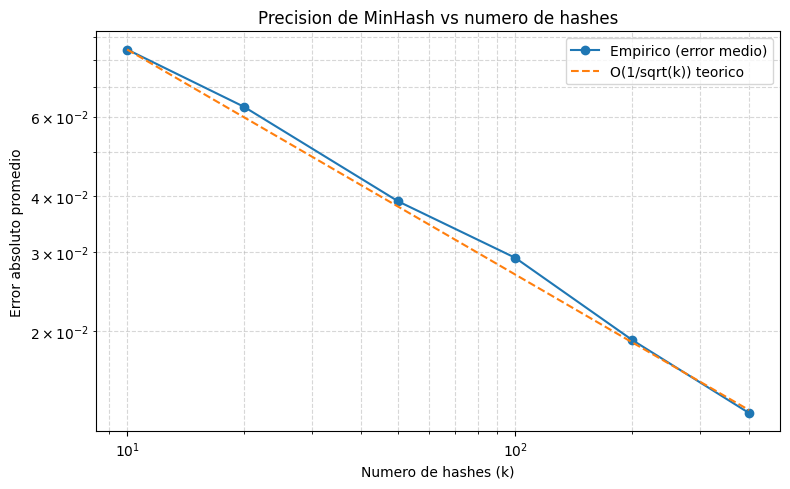

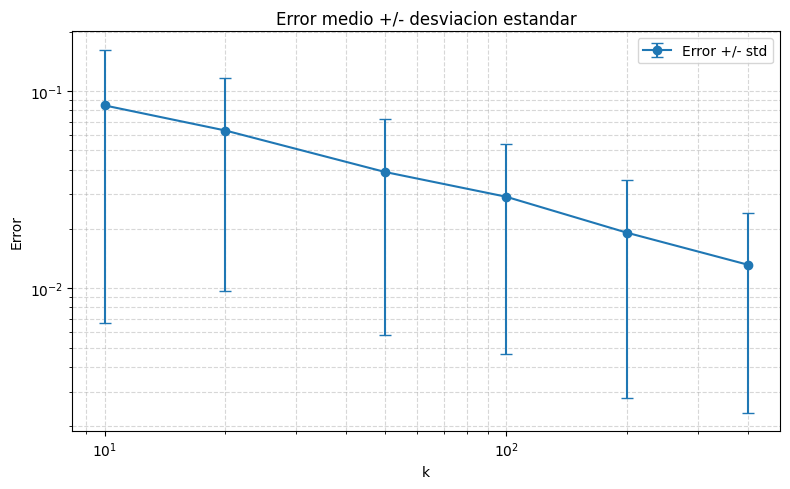

: 

In [ ]:
# -------------------------------
# Grafico log-log
# -------------------------------
plt.figure(figsize=(8, 5))
plt.loglog(num_hashes_list, means, 'o-', label='Empirico (error medio)')
plt.loglog(num_hashes_list, theoretical_scaled, '--', label='O(1/sqrt(k)) teorico')
plt.xlabel('Numero de hashes (k)')
plt.ylabel('Error absoluto promedio')
plt.title('Precision de MinHash vs numero de hashes')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(INFORME_DIR / 'lsh_error_loglog.png', dpi=120, bbox_inches='tight')
plt.show()

# -------------------------------
# Barras de error
# -------------------------------
plt.figure(figsize=(8, 5))
plt.errorbar(num_hashes_list, means, yerr=stds, fmt='o-', capsize=4, label='Error +/- std')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel('Error')
plt.title('Error medio +/- desviacion estandar')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(INFORME_DIR / 'lsh_error_std.png', dpi=120, bbox_inches='tight')
plt.show()


## 📊 Análisis de Complejidad

| Operación | Complejidad Temporal | Complejidad Espacial |
|-----------|---------------------|---------------------|
| `add_video(id, user_set)` | **O(\|user_set\| × h)** | O(h) por video |
| `find_similar(id, threshold)` | **O(b * r + \|candidatos\| * h)** | O(\|candidatos\|) |
| `jaccard_similarity(A, B)` | **O(\|A\| + \|B\|)** | O(\|A\| + \|B\|) |

donde `h` = num_hashes, `b` = num_bands, `r` = rows_per_band.

### Ventaja sobre Comparación Exhaustiva

| Enfoque | Complejidad | Para 1M videos |
|---------|------------|----------------|
| Comparación par-a-par | O(n²) | 10¹² operaciones |
| **LSH + MinHash** | **O(n)** aprox | **~10⁶ operaciones** |

LSH es aproximadamente **1,000,000x más rápido** para 1M videos, con pequeña pérdida de precisión controlable con los parámetros `b` y `r`.
